Purpose: Find genes (CAM-annotated & other) overlapping between time-structured (and/or DE), ASE, and HybridExpress gene sets.<br>
Author: Anna Pardo<br>
Date initiated: May 6, 2026

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from venn import venn
import json

In [2]:
# load time-structured DE gene info
ygde = pd.read_csv("/home/leviathan22/yucca-genomics/masigpro/Yg_maSigPro_DEGs_allphys.txt",sep="\t",header="infer")
ygde.head()

,GeneID,nsets,phys,species
0,YufilH1064049m.g,10,CAM,Yg
1,YufilH1024614m.g,9,CAM,Yg
2,Yucal.17G091000.v2.1,9,CAM,Yg
3,Yucal.15G051100.v2.1,9,CAM,Yg
4,Yucal.17G065400.v2.1,9,CAM,Yg


In [3]:
# load time-structured genes (regardless of DE)
c3cam = pd.read_csv("/home/leviathan22/yucca-genomics/masigpro/C3+CAM_TSgenes_9gt.txt",sep="\t",header="infer")
cam = pd.read_csv("/home/leviathan22/yucca-genomics/masigpro/CAM_TSgenes_9gt.txt",sep="\t",header="infer")
faccam = pd.read_csv("/home/leviathan22/yucca-genomics/masigpro/facCAM_TSgenes_9gt.txt",sep="\t",header="infer")

In [4]:
cam.head()

,GeneID,subgenome,physiology
0,Yucal.12G110700.v2.1,Ya,CAM
1,YufilH1093583m.g,Yf,CAM
2,Yucal.04G084700.v2.1,Ya,CAM
3,Yucal.10G075200.v2.1,Ya,CAM
4,Yucal.03G222100.v2.1,Ya,CAM


In [5]:
allts = pd.concat([c3cam,cam,faccam])

In [6]:
# load CAM annotation (will probably need this)
camannot = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",
                 sep="\t",header="infer")
camannot.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [7]:
# load ASE info
ase = pd.read_csv("/home/leviathan22/yucca-genomics/differential_expression/ASE_gttreat_output.txt",sep="\t",header="infer")
ase.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast
0,67.211469,0.764897,0.089259,8.569367,1.040554e-17,4.892090e-17,recip_syn2,18_W_aloifolia-V-18_W_filamentosa
1,207.226297,-0.485237,0.071331,-6.802606,1.027436e-11,3.495057e-11,recip_syn3,18_W_aloifolia-V-18_W_filamentosa
2,43.434762,0.344017,0.106880,3.218711,1.287680e-03,2.321305e-03,recip_syn4,18_W_aloifolia-V-18_W_filamentosa
3,52.217998,-1.184873,0.103213,-11.479849,1.665721e-30,1.346501e-29,recip_syn5,18_W_aloifolia-V-18_W_filamentosa
4,390.928299,-0.320654,0.073987,-4.333917,1.464794e-05,3.195546e-05,recip_syn7,18_W_aloifolia-V-18_W_filamentosa


In [8]:
# load HybridExpress info
he = pd.read_csv("/home/leviathan22/yucca-genomics/differential_expression/expression_partitioning_downstream/hybexp_top30pct_partitiongenes_bygttreat.txt",
                sep="\t",header="infer")
he.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D


In [9]:
# load syntelog info
synlong = pd.read_csv("/home/leviathan22/Yucca_genomics/yucca_synteny/reciprocal_syntelogs_sameinYaYf_long.txt",sep="\t",
                     header="infer")
synwide = pd.read_csv("/home/leviathan22/Yucca_genomics/yucca_synteny/reciprocal_syntelogs_sameinYaYf.txt",sep="\t",
                     header="infer")

In [10]:
synwide.head()

,Yf_GeneID,Ya_GeneID,syntelogID
0,YufilH1000002m.g,Yucal.01G000100.v2.1,recip_syn1
1,YufilH1000007m.g,Yucal.01G000200.v2.1,recip_syn2
2,YufilH1000011m.g,Yucal.01G000400.v2.1,recip_syn3
3,YufilH1000013m.g,Yucal.01G000500.v2.1,recip_syn4
4,YufilH1000018m.g,Yucal.01G000600.v2.1,recip_syn5


In [11]:
he = he.rename(columns={"Gene":"syntelogID"}).merge(synwide)
he.head()

,syntelogID,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,Yf_GeneID,Ya_GeneID
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D,YufilH1002639m.g,Yucal.01G117000.v2.1
1,recip_syn1000,5,UP,7.620442,1.210755,2AB_D,YufilH1002639m.g,Yucal.01G117000.v2.1
2,recip_syn1000,5,UP,7.999464,1.589465,1AB_D,YufilH1002639m.g,Yucal.01G117000.v2.1
3,recip_syn1000,1,ADD,5.807042,-0.594549,19_D,YufilH1002639m.g,Yucal.01G117000.v2.1
4,recip_syn1000,1,ADD,4.740206,-1.664001,G_D,YufilH1002639m.g,Yucal.01G117000.v2.1


In [12]:
ase = ase.rename(columns={"GeneID":"syntelogID"}).merge(synwide)
ase.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID
0,67.211469,0.764897,0.089259,8.569367,1.040554e-17,4.892090e-17,recip_syn2,18_W_aloifolia-V-18_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
1,67.211469,1.041007,0.096986,10.733621,7.076770e-27,4.864905e-26,recip_syn2,2AB_W_aloifolia-V-2AB_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
2,67.211469,0.825842,0.086364,9.562370,1.150902e-21,5.656733e-21,recip_syn2,2AB_D_aloifolia-V-2AB_D_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
3,67.211469,0.959057,0.096610,9.927104,3.173384e-23,2.005232e-22,recip_syn2,1AB_W_aloifolia-V-1AB_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
4,67.211469,0.924623,0.087605,10.554497,4.842263e-26,3.179247e-25,recip_syn2,18_D_aloifolia-V-18_D_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1


In [13]:
# load physiological categories
phys = json.load(open("/home/leviathan22/yucca-genomics/physiology/physiological_categories_from_TA.json"))

In [14]:
for k,v in phys.items():
    if v=="facultative CAM":
        phys[k] = "facultative_CAM"

In [15]:
he["genotype"] = he["genotype_treat"].str.split("_").str[0]
he["treat"] = he["genotype_treat"].str.split("_").str[1]

In [16]:
ase["genotype"] = ase["Contrast"].str.split("_").str[0]
ase["treat"] = ase["Contrast"].str.split("_").str[1]

In [17]:
ase["phys"] = ase["genotype"].map(phys)
he["phys"] = he["genotype"].map(phys)

In [18]:
ase["bias"] = np.where(ase["log2FoldChange"]>0,"Yf","Ya")

In [19]:
ase.columns

Index(['baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj',
       'syntelogID', 'Contrast', 'Yf_GeneID', 'Ya_GeneID', 'genotype', 'treat',
       'phys', 'bias'],
      dtype='object')

In [20]:
gid = []
for i in range(len(ase.index)):
    bias = ase.iloc[i,13]
    if bias=="Yf":
        gid.append(ase.iloc[i,8])
    else:
        gid.append(ase.iloc[i,9])

In [21]:
ase["GeneID"] = gid

In [22]:
# find overlaps for each physiology (& make a Venn diagram)
def phys_plot_venn(p,d="./",de=False):
    if not os.path.exists(d):
        os.makedirs(d)
    
    asesub = ase[ase["phys"]==p]
    hesub = he[he["phys"]==p]
    if de==False:
        tssub = allts[allts["physiology"]==p]
        label = "Time-Structured"
        fbase = p+"_venn_ASE_HE_TS"
    else:
        tssub = ygde[ygde["phys"]==p]
        label = "Differentially expressed"
        fbase = p+"_venn_ASE_HE_DE"
    
    # combine genes from both subgenomes for HybridExpress
    all_he_genes = list(hesub["Ya_GeneID"])+list(hesub["Yf_GeneID"])
    
    # assemble dictionary for Venn diagram construction
    venndict = {
        "ASE":set(list(asesub["GeneID"])),
        "HybridExpress":set(all_he_genes),
        label:set(list(tssub["GeneID"]))
    }
    
    venn(venndict)
    if "_" in p:
        p = p.split("_")[0]+" "+p.split("_")[1]
    plt.title(p+" Y. gloriosa gene overlaps",fontsize=20)
    
    plt.savefig(os.path.join(d,fbase+".png"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,fbase+".pdf"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,fbase+".svg"),dpi=300,bbox_inches="tight")

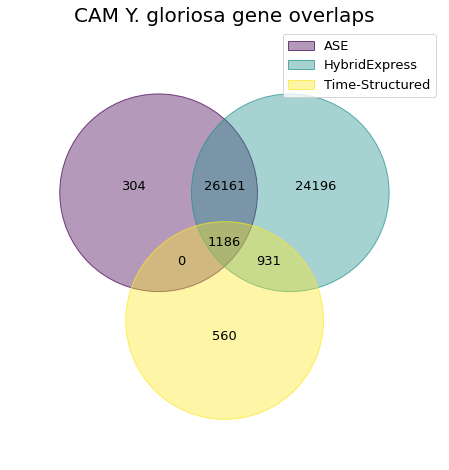

In [23]:
phys_plot_venn("CAM","./ASE_HE_maSigPro_venns")

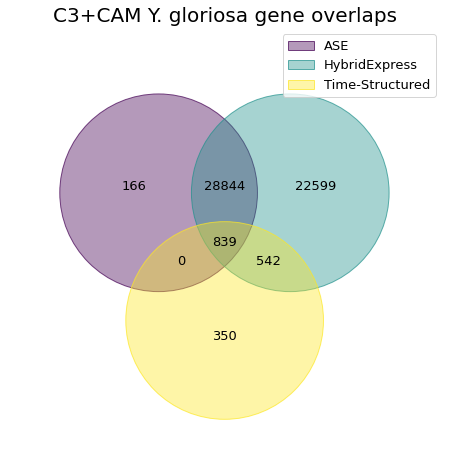

In [24]:
phys_plot_venn("C3+CAM","./ASE_HE_maSigPro_venns")

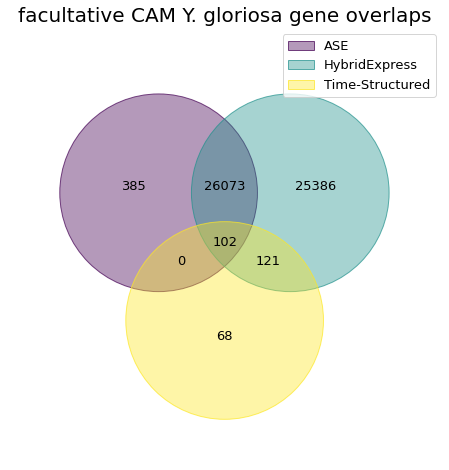

In [25]:
phys_plot_venn("facultative_CAM","./ASE_HE_maSigPro_venns")

In [26]:
# I am most interested in three-way overlaps at the moment - extract those genes
def get_3way_int(p):
    asesub = ase[ase["phys"]==p]
    hesub = he[he["phys"]==p]
    tssub = allts[allts["physiology"]==p]
    
    # combine genes from both subgenomes for HybridExpress
    all_he_genes = list(hesub["Ya_GeneID"])+list(hesub["Yf_GeneID"])
    
    # extract intersection from list of sets
    int3 = set.intersection(*[set(list(asesub["GeneID"])),set(list(tssub["GeneID"])),set(all_he_genes)])
    return list(int3)

In [27]:
cam_int = get_3way_int("CAM")
c3cam_int = get_3way_int("C3+CAM")
fac_int = get_3way_int("facultative_CAM")

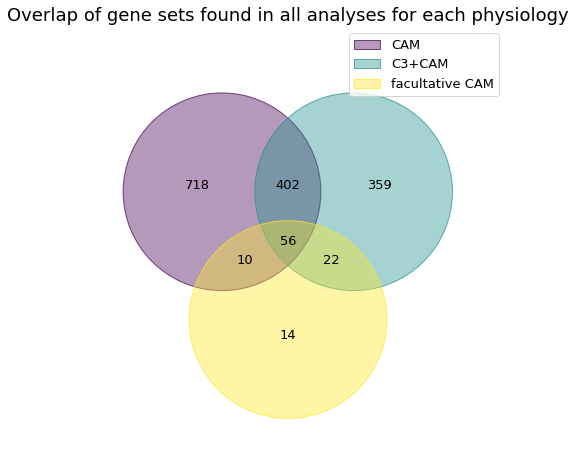

In [28]:
venn({"CAM":set(cam_int),"C3+CAM":set(c3cam_int),"facultative CAM":set(fac_int)})
plt.title("Overlap of gene sets found in all analyses for each physiology",fontsize=18)

plt.savefig("./ASE_HE_maSigPro_venns/3wayints_venn.png",dpi=300,bbox_inches="tight")
plt.savefig("./ASE_HE_maSigPro_venns/3wayints_venn.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./ASE_HE_maSigPro_venns/3wayints_venn.svg",dpi=300,bbox_inches="tight")

In [29]:
camannot.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [30]:
# what CAM genes are present in each of these lists?
camgenes = list(camannot["GeneID"].unique())

In [31]:
camint_cam = [i for i in cam_int if i in camgenes]
c3int_cam = [i for i in c3cam_int if i in camgenes]
facint_cam = [i for i in fac_int if i in camgenes]

In [32]:
len(camint_cam)

0

In [33]:
len(c3int_cam)

0

In [34]:
len(facint_cam)

1

In [35]:
facint_cam

['YufilH1062820m.g']

In [36]:
camannot[camannot["GeneID"].isin(facint_cam)]

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
77,YufilH1062820m.g,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Yf_PPDK_1,Yf


In [37]:
# re-make venn diagrams for known CAM genes only
def phys_cam_venn(p,d="./",de=False,camlist=camgenes):
    if not os.path.exists(d):
        os.makedirs(d)
    
    asesub = ase[(ase["phys"]==p) & (ase["GeneID"].isin(camlist))]
    hesub = he[he["phys"]==p]
    if de==False:
        tssub = allts[(allts["physiology"]==p) & (allts["GeneID"].isin(camlist))]
        label = "Time-Structured"
        fbase = p+"_vennCAMgenes_ASE_HE_TS"
    else:
        tssub = ygde[(ygde["phys"]==p) & (ygde["GeneID"].isin(camlist))]
        label = "Differentially expressed"
        fbase = p+"_vennCAMgenes_ASE_HE_DE"
    
    # combine genes from both subgenomes for HybridExpress
    all_he_genes = list(hesub["Ya_GeneID"])+list(hesub["Yf_GeneID"])
    all_he_genes = [i for i in all_he_genes if i in camlist]
    
    # assemble dictionary for Venn diagram construction
    venndict = {
        "ASE":set(list(asesub["GeneID"])),
        "HybridExpress":set(all_he_genes),
        label:set(list(tssub["GeneID"]))
    }
    
    venn(venndict)
    if "_" in p:
        p = p.split("_")[0]+" "+p.split("_")[1]
    plt.title(p+" Y. gloriosa CAM gene overlaps",fontsize=20)
    
    plt.savefig(os.path.join(d,fbase+".png"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,fbase+".pdf"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,fbase+".svg"),dpi=300,bbox_inches="tight")

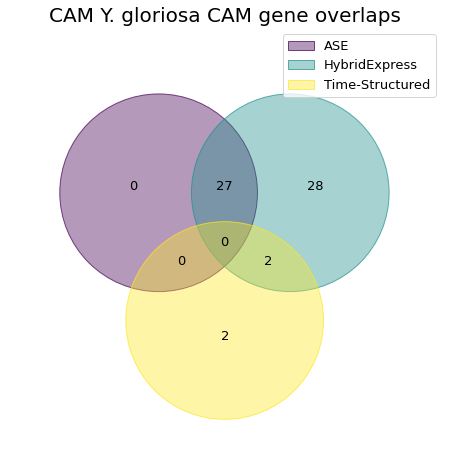

In [38]:
phys_cam_venn("CAM")

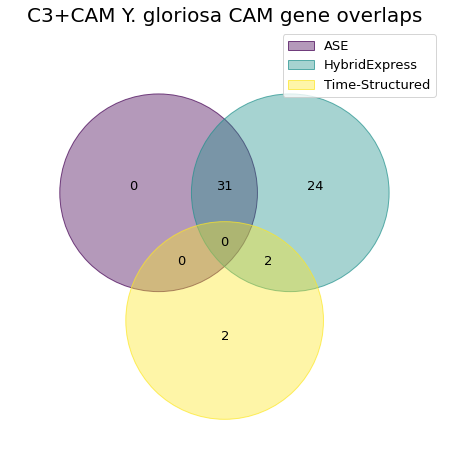

In [39]:
phys_cam_venn("C3+CAM")

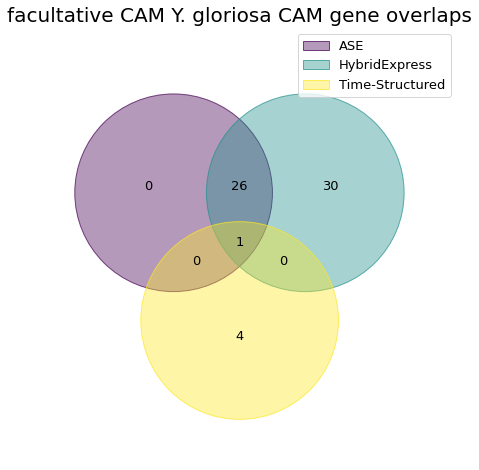

In [40]:
phys_cam_venn("facultative_CAM")

In [41]:
# save intersection gene lists as JSON
intdict = {
    "CAM":cam_int,"C3+CAM":c3cam_int,"facultative CAM":fac_int
}

In [42]:
with open("./3wayint_HE_ASE_TS_eachphys.json","w+") as outfile:
    json.dump(intdict,outfile)

## May 8, 2026: Find intersections between HybridExpress & TS results

In [43]:
def get_int_hets(p):
    hesub = he[he["phys"]==p]
    tssub = allts[allts["physiology"]==p]
    
    # combine genes from both subgenomes for HybridExpress
    all_he_genes = list(hesub["Ya_GeneID"])+list(hesub["Yf_GeneID"])
    
    # extract intersection from list of sets
    inter = set.intersection(*[set(list(tssub["GeneID"])),set(all_he_genes)])
    return list(inter)

In [44]:
cam_hets = get_int_hets("CAM")
c3_hets = get_int_hets("C3+CAM")
fac_hets = get_int_hets("facultative_CAM")

In [45]:
len(cam_hets)

2117

In [46]:
len(c3_hets)

1381

In [47]:
len(fac_hets)

223

In [48]:
# save each of these gene sets for GO enrichment & other downstream analysis
with open("./YgCAM_HybExp_TS_intgenes.txt","w+") as outfile:
    for i in cam_hets:
        outfile.write(i+"\n")

In [49]:
with open("./YgC3+CAM_HybExp_TS_intgenes.txt","w+") as outfile:
    for i in c3_hets:
        outfile.write(i+"\n")

In [50]:
with open("./YgfacCAM_HybExp_TS_intgenes.txt","w+") as outfile:
    for i in fac_hets:
        outfile.write(i+"\n")

In [51]:
# visualize overlaps between each HybridExpress class & time-structured genes (for each physiotype): UpSet plotting
import upsetplot

In [52]:
he.head()

,syntelogID,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,Yf_GeneID,Ya_GeneID,genotype,treat,phys
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D,YufilH1002639m.g,Yucal.01G117000.v2.1,18,D,C3+CAM
1,recip_syn1000,5,UP,7.620442,1.210755,2AB_D,YufilH1002639m.g,Yucal.01G117000.v2.1,2AB,D,C3+CAM
2,recip_syn1000,5,UP,7.999464,1.589465,1AB_D,YufilH1002639m.g,Yucal.01G117000.v2.1,1AB,D,C3+CAM
3,recip_syn1000,1,ADD,5.807042,-0.594549,19_D,YufilH1002639m.g,Yucal.01G117000.v2.1,19,D,C3+CAM
4,recip_syn1000,1,ADD,4.740206,-1.664001,G_D,YufilH1002639m.g,Yucal.01G117000.v2.1,G,D,facultative_CAM


In [53]:
allts.head()

,GeneID,subgenome,physiology
0,YufilH1068918m.g,Yf,C3+CAM
1,Yucal.02G260900.v2.1,Ya,C3+CAM
2,Yucal.15G058600.v2.1,Ya,C3+CAM
3,YufilH1007932m.g,Yf,C3+CAM
4,YufilH1093291m.g,Yf,C3+CAM


In [54]:
# make a dict with structure: key=class/gene group, value=list of genes
## define a function to do this 
def make_upset_dict(ptype):
    tssub = allts[allts["physiology"]==ptype]
    hesub = he[he["phys"]==ptype]
    
    outdict = {"Time-structured":list(tssub["GeneID"].unique())}
    
    for c in hesub["Class"].unique():
        df = hesub[hesub["Class"]==c]
        outdict[c] = list(df["Ya_GeneID"].unique())+list(df["Yf_GeneID"].unique())
        
    return outdict

In [55]:
# make a function to do plotting
def plot_upset(ptype,d="./"):
    if not os.path.exists(d):
        os.makedirs(d)
    
    # make plotting dict
    plotdict = make_upset_dict(ptype)
    
    # convert to dataframe formatted for upsetplot
    plotdf = upsetplot.from_contents(plotdict)
    
    if "_" in ptype:
        ptype1 = ptype.split("_")[0]+" "+ptype.split("_")[1]
    else:
        ptype1 = ptype
    
    # make the plot
    upsetplot.plot(plotdf,show_counts=True,sort_by="-degree",sort_categories_by="-cardinality")
    plt.title("Intersections between time-structured & parent-hybrid DE genes in "+ptype1+" Y. gloriosa",
             fontsize=28,pad=30)
    
    fbase = ptype+"_upsetplot_HybExp_TSgenes"
    plt.savefig(os.path.join(d,fbase+".png"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,fbase+".pdf"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,fbase+".svg"),dpi=300,bbox_inches="tight")

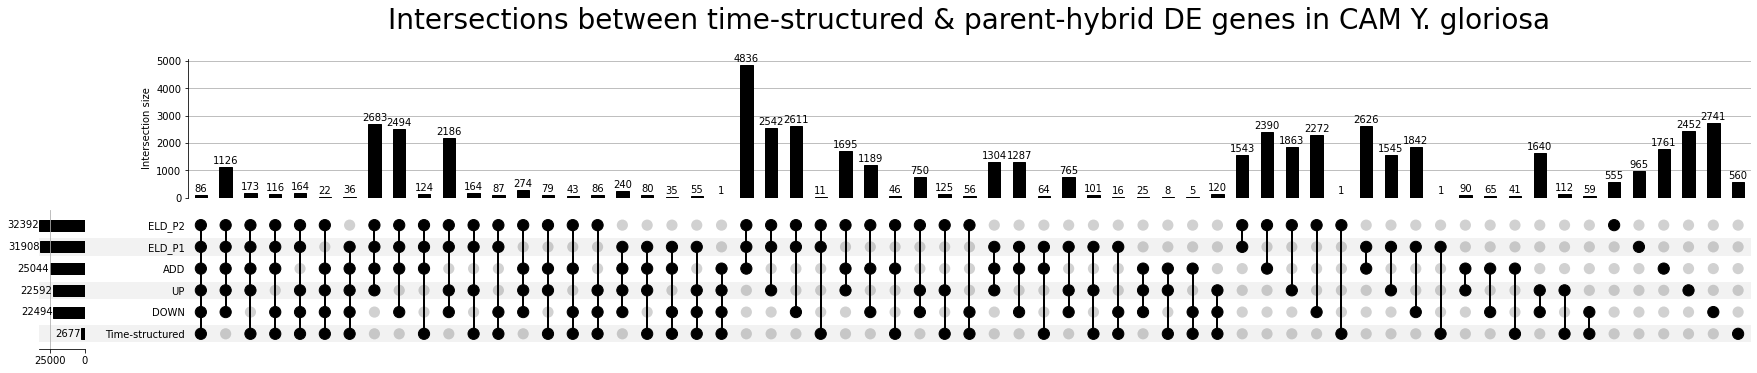

In [56]:
plot_upset("CAM","./ASE_HE_maSigPro_venns/")

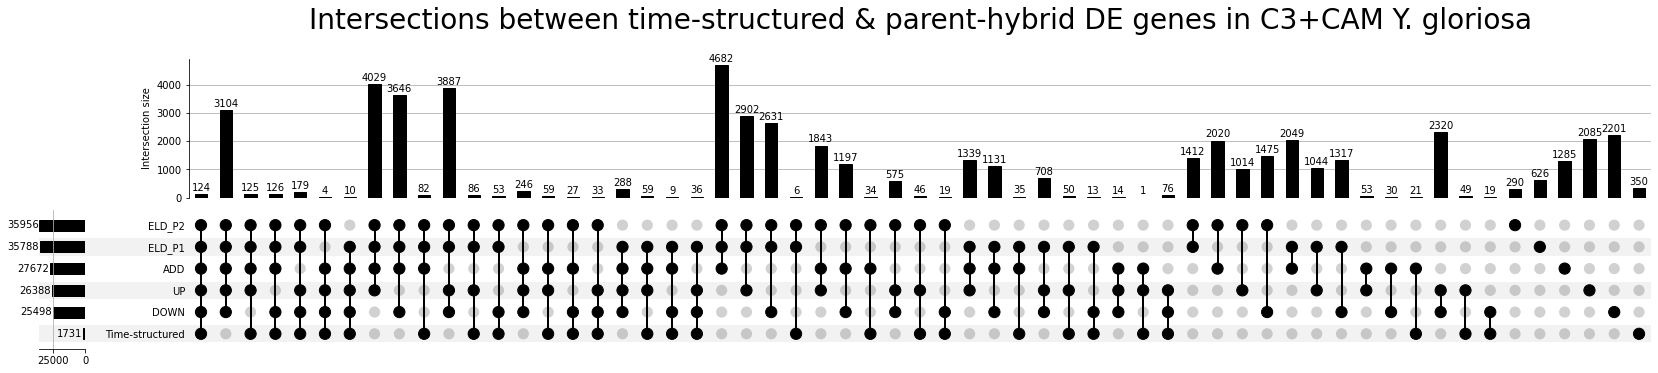

In [57]:
plot_upset("C3+CAM","./ASE_HE_maSigPro_venns/")

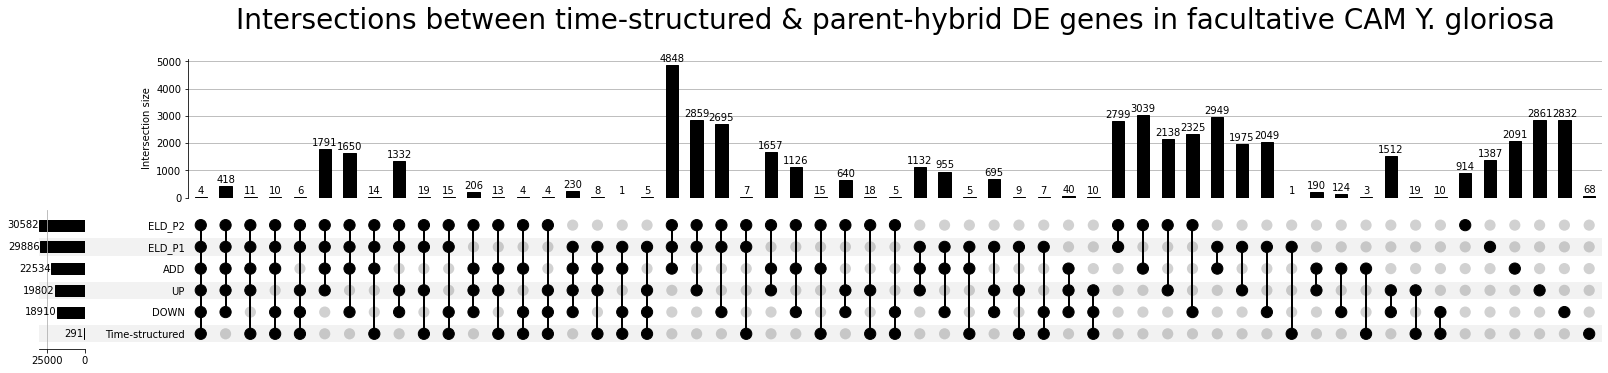

In [58]:
plot_upset("facultative_CAM","./ASE_HE_maSigPro_venns/")

In [60]:
make_upset_dict("CAM").keys()

dict_keys(['Time-structured', 'UP', 'ADD', 'ELD_P2', 'ELD_P1', 'DOWN'])

In [63]:
# May 11, 2026
# find & save intersections (for each physiotype) between TS genes & each HE category
def get_allHEints(ptype,save=True,d="./"):
    glists = make_upset_dict(ptype)
    tsints = {}
    for k,v in glists.items():
        if k!="Time-structured":
            tsints[k] = list(set(glists["Time-structured"]).intersection(set(v)))
    if save:
        with open(os.path.join(d,ptype+"_TS_HybExp_classints.json"),"w+") as outfile:
            json.dump(tsints,outfile)
    return tsints

In [65]:
camhe = get_allHEints("CAM")

In [66]:
c3he = get_allHEints("C3+CAM")

In [67]:
fache = get_allHEints("facultative_CAM")

In [2]:
# re-load each of these files to find how many genes are in each intersection (for making a supplemental table)
camhe = json.load(open("./CAM_TS_HybExp_classints.json"))
c3he = json.load(open("./C3+CAM_TS_HybExp_classints.json"))
fache = json.load(open("./facultative_CAM_TS_HybExp_classints.json"))

In [6]:
for k,v in fache.items():
    print("Number of genes in "+k+" : "+str(len(v)))

Number of genes in ADD : 88
Number of genes in UP : 126
Number of genes in ELD_P2 : 145
Number of genes in ELD_P1 : 122
Number of genes in DOWN : 81


In [3]:
# load CAM gene annotation
## May 27, 2026
camannot = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",
                 sep="\t",header="infer")

In [4]:
camannot.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [6]:
# find CAM genes in the HybridExpress - TS intersections
def findcam(d):
    outd = {}
    for k,v in d.items():
        outd[k] = [i for i in v if i in list(camannot["GeneID"].unique())]
    return outd

In [8]:
cam_hets_cg = findcam(camhe)

In [9]:
fac_hets_cg = findcam(fache)

In [11]:
c3cam_hets_cg = findcam(c3he)

In [12]:
def findcam_genenames(d):
    outd = {}
    for k,v in d.items():
        gids = [i for i in v if i in list(camannot["GeneID"].unique())]
        df = camannot[camannot["GeneID"].isin(gids)]
        outd[k] = list(df["gene_abbr_unique"].unique())
    return outd

In [13]:
cam_gnames = findcam_genenames(camhe)

In [14]:
fac_gnames = findcam_genenames(fache)

In [15]:
c3cam_gnames = findcam_genenames(c3he)

In [16]:
cam_gnames

{'UP': ['Ya_PPDK_1', 'Yf_PPDK_1'],
 'ADD': [],
 'ELD_P2': ['Ya_PPDK_1', 'Yf_PPDK_1'],
 'ELD_P1': ['Ya_PPDK_1', 'Yf_PPDK_1'],
 'DOWN': ['Ya_PPDK_1', 'Yf_PPDK_1']}

In [17]:
fac_gnames

{'ADD': [],
 'UP': ['Yf_PPDK_1'],
 'ELD_P2': ['Yf_PPDK_1'],
 'ELD_P1': ['Yf_PPDK_1'],
 'DOWN': []}

In [18]:
c3cam_gnames

{'ADD': [],
 'UP': ['Ya_PPDK_1', 'Yf_PPDK_1'],
 'ELD_P2': ['Ya_PPDK_1', 'Yf_PPDK_1'],
 'DOWN': ['Ya_PPDK_1', 'Yf_PPDK_1'],
 'ELD_P1': ['Ya_PPDK_1', 'Yf_PPDK_1']}